# Case Study 4: Bankruptcy Prediction
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater

## Introduction

The Polish companies bankruptcy dataset contains 64 financial ratios for firms across five forecasting horizons, with a binary label indicating whether the firm later went bankrupt. We build cross validated Random Forest and XGBoost classifiers for each horizon, tune their hyperparameters, and compare our out of fold ROC AUC to the results published by Zieba et al. (2016). All reported metrics come from out of fold predictions.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

## Data Loading

Each of the five ARFF files has a 69 line header, so we skip it and read the raw rows, with `?` marking missing values. We name the features X1 through X64 to match the paper.

In [2]:
years = [1, 2, 3, 4, 5]
feature_names = [f"X{i}" for i in range(1, 65)]

bankruptcy_data = {}
for year in years:
    year_data = pd.read_csv(f"./data/{year}year.arff", skiprows=69, header=None, na_values="?")
    year_data.columns = feature_names + ["bankrupt"]
    bankruptcy_data[year] = year_data

for year in years:
    print(f"{year}year: {bankruptcy_data[year].shape}")

1year: (7027, 65)
2year: (10173, 65)
3year: (10503, 65)
4year: (9792, 65)
5year: (5910, 65)


## EDA

Every horizon is heavily imbalanced, with bankruptcy rates in the single digits. Accuracy would look great on a model that never predicts bankruptcy, which drives our metric choice later.

In [3]:
class_balance = pd.DataFrame({
    year: bankruptcy_data[year]["bankrupt"].value_counts() for year in years
}).T
class_balance["bankrupt_rate"] = class_balance[1] / (class_balance[0] + class_balance[1])
class_balance

bankrupt,0,1,bankrupt_rate
1,6756,271,0.038566
2,9773,400,0.039320
3,10008,495,0.047129
4,9277,515,0.052594
5,5500,410,0.069374


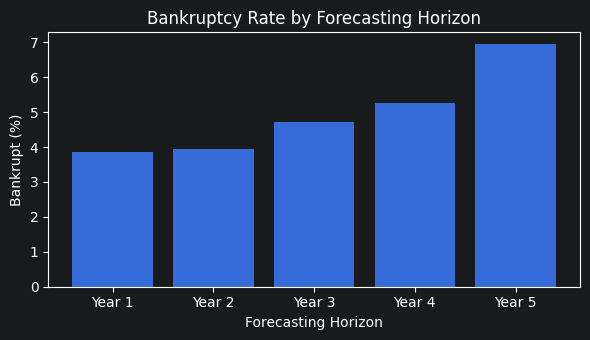

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar([f"Year {y}" for y in years], class_balance["bankrupt_rate"] * 100)
ax.set_xlabel("Forecasting Horizon")
ax.set_ylabel("Bankrupt (%)")
ax.set_title("Bankruptcy Rate by Forecasting Horizon")
plt.tight_layout()
plt.show()

Missing values are widespread but concentrated in a few columns. X37 is missing in over a third of year 1 rows and X21 in almost a quarter, so we impute rather than drop.

In [5]:
missing_counts = pd.DataFrame({
    year: bankruptcy_data[year][feature_names].isna().sum() for year in years
})
missing_counts[missing_counts.max(axis=1) > 0].sort_values(1, ascending=False).head(10)

,1,2,3,4,5
X37,2740,4518,4736,4442,2548
X21,1622,3164,807,158,103
X27,311,706,715,641,391
X60,135,543,592,614,268
X45,134,541,591,613,268
X24,124,225,227,211,135
X41,84,197,202,187,84
X11,39,1,0,1,3
X32,38,87,101,96,46
X54,34,212,228,231,107


In [6]:
bankruptcy_data[1][feature_names].describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False).head(10)

,mean,std,min,max
X43,4588.503542,362730.934024,0.000000e+00,30393000.0
X62,4763.201955,310783.483587,0.000000e+00,25016000.0
X44,3426.404199,269621.104411,0.000000e+00,22584000.0
X20,1162.127976,93158.220665,0.000000e+00,7809200.0
X15,1802.696106,83922.323322,-5.611900e+06,3599100.0
X55,8855.693294,72475.270699,-8.004700e+05,4398400.0
X5,-263.167247,37074.596449,-2.722100e+06,990900.0
X27,1321.989035,35504.159662,-1.479000e+04,2040800.0
X60,432.882958,26128.019222,4.700000e-05,2137800.0
X56,-157.736739,13221.247567,-1.108300e+06,1.0


The ratios have extreme ranges, with some columns spanning several orders of magnitude in both directions. These are real financial ratios with small denominators, not data errors, and tree models handle them without transformation.

## Imputation

We fill missing values with the column mean using SimpleImputer, matching the approach from the guidelines. The target column has no missing values.

In [7]:
for year in years:
    mean_imputer = SimpleImputer(strategy="mean")
    bankruptcy_data[year][feature_names] = mean_imputer.fit_transform(bankruptcy_data[year][feature_names])

remaining = sum(bankruptcy_data[year].isna().sum().sum() for year in years)
print(f"Missing values remaining: {remaining}")

Missing values remaining: 0


## Scaling

Random Forest and XGBoost split on feature thresholds, so scaling the inputs does not change the splits or the predictions. We leave the features unscaled.

## Random Forest

We tune four hyperparameters with a cross validated grid search on each year, scoring by ROC AUC. AUC is our metric because the classes are heavily imbalanced, it is threshold independent, and it is what the paper reports, so the comparison is direct. The number of trees is fixed at 100 since more trees only helps Random Forest and it is not a hyperparameter we may tune.

In [8]:
rf_param_grid = {
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 8, 16],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.25, 0.5],
}

rf_best_params = {}
rf_grid_results = {}
for year in years:
    year_features = bankruptcy_data[year][feature_names]
    year_target = bankruptcy_data[year]["bankrupt"]
    rf_grid = GridSearchCV(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        rf_param_grid, scoring="roc_auc", cv=5,
    )
    rf_grid.fit(year_features, year_target)
    rf_best_params[year] = rf_grid.best_params_
    rf_grid_results[year] = pd.DataFrame(rf_grid.cv_results_)
    print(f"{year}year best CV AUC: {rf_grid.best_score_:.3f}  {rf_grid.best_params_}")

1year best CV AUC: 0.931  {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 2}
2year best CV AUC: 0.890  {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 16}
3year best CV AUC: 0.895  {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 16}
4year best CV AUC: 0.905  {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 2}
5year best CV AUC: 0.945  {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 2}


The top five parameter combinations per year, ranked by mean CV AUC.

In [9]:
rf_tuning_summary = pd.concat({
    year: rf_grid_results[year].sort_values("rank_test_score")[
        ["params", "mean_test_score", "std_test_score"]
    ].head(5)
    for year in years
})
rf_tuning_summary

params  mean_test_score  \
1 24  {'max_depth': 10, 'max_features': 0.5, 'min_sa...         0.930817   
  25  {'max_depth': 10, 'max_features': 0.5, 'min_sa...         0.930817   
  51  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.929312   
  52  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.929312   
  78  {'max_depth': None, 'max_features': 0.5, 'min_...         0.929062   
2 80  {'max_depth': None, 'max_features': 0.5, 'min_...         0.889879   
  53  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.889477   
  46  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.889003   
  45  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.888450   
  78  {'max_depth': None, 'max_features': 0.5, 'min_...         0.887727   
3 26  {'max_depth': 10, 'max_features': 0.5, 'min_sa...         0.895363   
  24  {'max_depth': 10, 'max_features': 0.5, 'min_sa...         0.893754   
  25  {'max_depth': 10, 'max_features': 0.5, 'min_sa...         0.893754   
  21  {'max_depth': 10, 'max_features': 0.5, 'min_sa...         0.892720   
  23  {'max_depth': 10, 'max_features': 0.5, 'min_sa...         0.892626   
4 78  {'max_depth': None, 'max_features': 0.5, 'min_...         0.904881   
  79  {'max_depth': None, 'max_features': 0.5, 'min_...         0.904881   
  51  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.903884   
  52  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.903884   
  76  {'max_depth': None, 'max_features': 0.5, 'min_...         0.900751   
5 48  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.944812   
  47  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.944779   
  74  {'max_depth': None, 'max_features': 0.5, 'min_...         0.944073   
  75  {'max_depth': None, 'max_features': 0.5, 'min_...         0.942840   
  53  {'max_depth': 20, 'max_features': 0.5, 'min_sa...         0.942693   

      std_test_score  
1 24        0.030811  
  25        0.030811  
  51        0.027996  
  52        0.027996  
  78        0.027506  
2 80        0.034466  
  53        0.032127  
  46        0.037843  
  45        0.035684  
  78        0.040539  
3 26        0.038138  
  24        0.038285  
  25        0.038285  
  21        0.041058  
  23        0.042779  
4 78        0.027503  
  79        0.027503  
  51        0.027120  
  52        0.027120  
  76        0.033821  
5 48        0.016269  
  47        0.015788  
  74        0.016893  
  75        0.015372  
  53        0.017360

The tuning is dominated by max_features, with 0.5 winning in every top combination across all five years. A leaf size of 4 takes four of the five years, and once those two are set, depth and split size barely move the score. Best CV AUC ranges from 0.890 in year 2 to 0.945 in year 5.

With the best parameters per year we refit under 10 fold stratified CV, matching the paper's 10 folds, and collect out of fold probabilities and per fold AUCs.

In [10]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

rf_fold_aucs = {}
rf_oof_proba = {}
for year in years:
    year_features = bankruptcy_data[year][feature_names].values
    year_target = bankruptcy_data[year]["bankrupt"].values
    oof_proba = np.zeros(len(year_target))
    fold_aucs = []
    for train_idx, val_idx in skf.split(year_features, year_target):
        rf_model = RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, **rf_best_params[year]
        )
        rf_model.fit(year_features[train_idx], year_target[train_idx])
        val_proba = rf_model.predict_proba(year_features[val_idx])[:, 1]
        oof_proba[val_idx] = val_proba
        fold_aucs.append(roc_auc_score(year_target[val_idx], val_proba))
    rf_fold_aucs[year] = fold_aucs
    rf_oof_proba[year] = oof_proba
    print(f"{year}year OOF AUC: {np.mean(fold_aucs):.3f} +/- {np.std(fold_aucs, ddof=1):.3f}")

1year OOF AUC: 0.926 +/- 0.024
2year OOF AUC: 0.904 +/- 0.033
3year OOF AUC: 0.904 +/- 0.023
4year OOF AUC: 0.916 +/- 0.023
5year OOF AUC: 0.944 +/- 0.023


### Comparison to Paper Results

The paper reports mean and standard deviation of AUC over 10 CV folds for Random Forest (Table 3). Since both sides summarize 10 folds, we use a Welch two sample t-test from the summary statistics to check whether the differences are significant.

In [11]:
paper_rf_auc = {1: (0.851, 0.044), 2: (0.842, 0.028), 3: (0.831, 0.031), 4: (0.848, 0.027), 5: (0.898, 0.035)}

comparison_rows = []
for year in years:
    our_mean = np.mean(rf_fold_aucs[year])
    our_std = np.std(rf_fold_aucs[year], ddof=1)
    paper_mean, paper_std = paper_rf_auc[year]
    t_stat, p_value = stats.ttest_ind_from_stats(
        our_mean, our_std, 10, paper_mean, paper_std, 10, equal_var=False
    )
    comparison_rows.append([year, our_mean, our_std, paper_mean, paper_std, t_stat, p_value])

rf_comparison = pd.DataFrame(
    comparison_rows,
    columns=["year", "our_auc", "our_std", "paper_auc", "paper_std", "t_stat", "p_value"]
)
rf_comparison.round(3)

,year,our_auc,our_std,paper_auc,paper_std,t_stat,p_value
0,1,0.926,0.024,0.851,0.044,4.715,0.000
1,2,0.904,0.033,0.842,0.028,4.509,0.000
2,3,0.904,0.023,0.831,0.031,5.934,0.000
3,4,0.916,0.023,0.848,0.027,6.102,0.000
4,5,0.944,0.023,0.898,0.035,3.505,0.003


Our Random Forest beats the paper's reported RF in every year, with gains of 0.046 to 0.075 AUC, and the Welch test marks every difference as significant (p of 0.003 or lower). The paper treated Random Forest as a reference model, so the gap most likely reflects our per year grid search and possibly differences in imputation.

### Classification Report, Confusion Matrix, and ROC

All computed from out of fold predictions at the default 0.5 threshold:

In [12]:
for year in years:
    year_target = bankruptcy_data[year]["bankrupt"]
    oof_pred = (rf_oof_proba[year] >= 0.5).astype(int)
    print(f"----- {year}year -----")
    print(classification_report(year_target, oof_pred, target_names=["Solvent", "Bankrupt"]))

----- 1year -----
              precision    recall  f1-score   support

     Solvent       0.98      1.00      0.99      6756
    Bankrupt       0.98      0.49      0.65       271

    accuracy                           0.98      7027
   macro avg       0.98      0.74      0.82      7027
weighted avg       0.98      0.98      0.98      7027

----- 2year -----
              precision    recall  f1-score   support

     Solvent       0.97      1.00      0.99      9773
    Bankrupt       1.00      0.36      0.53       400

    accuracy                           0.97     10173
   macro avg       0.99      0.68      0.76     10173
weighted avg       0.98      0.97      0.97     10173

----- 3year -----
              precision    recall  f1-score   support

     Solvent       0.97      1.00      0.98     10008
    Bankrupt       0.90      0.29      0.44       495

    accuracy                           0.96     10503
   macro avg       0.94      0.64      0.71     10503
weighted avg       0

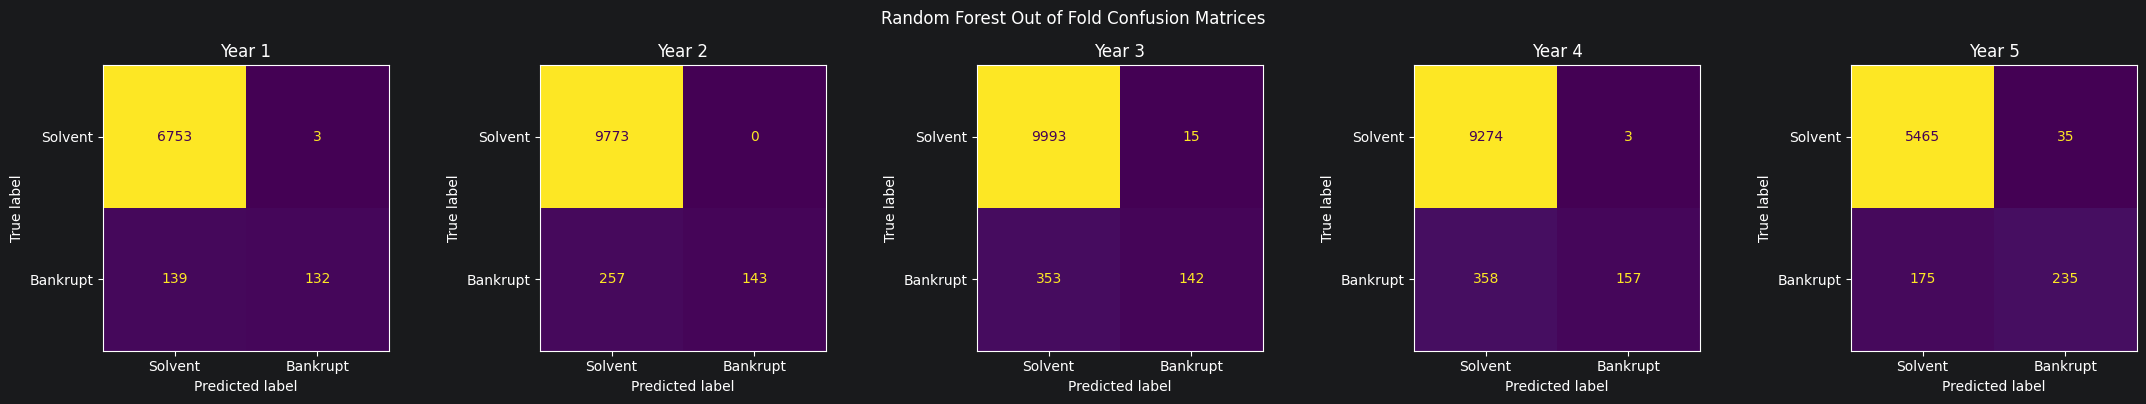

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, year in zip(axes, years):
    year_target = bankruptcy_data[year]["bankrupt"]
    oof_pred = (rf_oof_proba[year] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        year_target, oof_pred, display_labels=["Solvent", "Bankrupt"], ax=ax, colorbar=False
    )
    ax.set_title(f"Year {year}")
fig.suptitle("Random Forest Out of Fold Confusion Matrices")
plt.tight_layout()
plt.show()

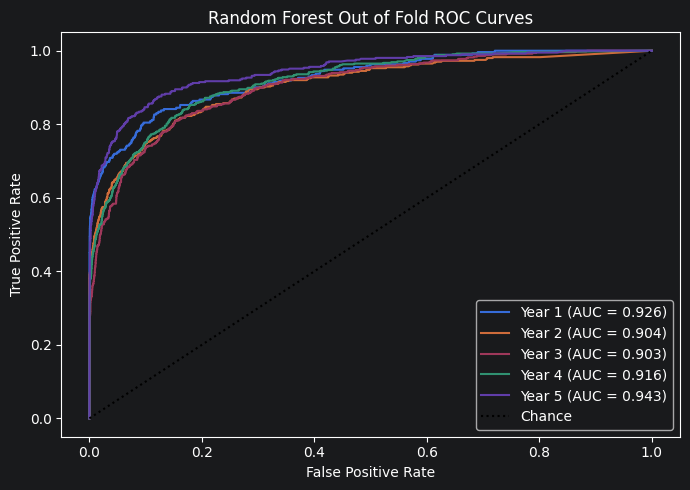

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
for year in years:
    year_target = bankruptcy_data[year]["bankrupt"]
    fpr, tpr, _ = roc_curve(year_target, rf_oof_proba[year])
    oof_auc = roc_auc_score(year_target, rf_oof_proba[year])
    ax.plot(fpr, tpr, label=f"Year {year} (AUC = {oof_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="dotted", color="black", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Random Forest Out of Fold ROC Curves")
ax.legend()
plt.tight_layout()
plt.show()

At the 0.5 threshold the model is very conservative. Precision on the bankrupt class is 0.87 or higher every year, but recall runs from 0.29 in year 3 to 0.57 in year 5, so most bankruptcies are missed. The confusion matrices show almost no false alarms, between 0 and 35 per year, at the cost of hundreds of missed bankruptcies, which is the expected tradeoff when positives are 4 to 7 percent of the data. Year 5, the horizon closest to the bankruptcy event, is clearly the easiest at 0.944 AUC and also posts the best recall. A lower threshold would trade some precision for recall if catching more bankruptcies mattered to the business.

### Grid Search versus Random Search

We compare a full grid search (81 combinations) against a random search capped at 15 iterations on the year 1 data only, same grid and scoring, and time both.

In [15]:
%%time
year1_features = bankruptcy_data[1][feature_names]
year1_target = bankruptcy_data[1]["bankrupt"]

grid_timing = GridSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    rf_param_grid, scoring="roc_auc", cv=5,
)
grid_timing.fit(year1_features, year1_target)
print(f"Grid search best AUC: {grid_timing.best_score_:.3f}")

Grid search best AUC: 0.931
CPU times: user 31min 12s, sys: 5.89 s, total: 31min 18s
Wall time: 1min 49s


In [16]:
%%time
random_timing = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    rf_param_grid, n_iter=15, scoring="roc_auc", cv=5, random_state=42,
)
random_timing.fit(year1_features, year1_target)
print(f"Random search best AUC: {random_timing.best_score_:.3f}")

Random search best AUC: 0.926
CPU times: user 4min 49s, sys: 1.12 s, total: 4min 50s
Wall time: 17.7 s


Random search landed within 0.005 AUC of the full grid (0.926 versus 0.931) while finishing in roughly 20 seconds against roughly 2 minutes, about a sixth of the wall time for 15 of the 81 combinations. That tradeoff justifies random sampling for the much larger XGBoost search space below.

## XGBoost

We tune six hyperparameters with three values each using the native XGBoost package. The full grid is 729 combinations, which is impractical, so following the grid versus random search result above we sample 15 random configurations and evaluate each with `xgb.cv` under 5 fold CV. Every run uses early stopping with a large round budget, so the number of trees is governed by early stopping rather than tuned. Scoring is ROC AUC for the same reasons as Random Forest.

In [17]:
xgb_param_space = {
    "eta": [0.05, 0.1, 0.3],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 1, 5],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.5, 0.75, 1.0],
}

rng = np.random.default_rng(42)
xgb_candidates = []
for i in range(15):
    candidate = {name: values[rng.integers(len(values))] for name, values in xgb_param_space.items()}
    xgb_candidates.append(candidate)

xgb_candidates[:3]

[{'eta': 0.05,
  'max_depth': 7,
  'min_child_weight': 3,
  'gamma': 1,
  'subsample': 0.85,
  'colsample_bytree': 1.0},
 {'eta': 0.05,
  'max_depth': 7,
  'min_child_weight': 1,
  'gamma': 0,
  'subsample': 0.85,
  'colsample_bytree': 1.0},
 {'eta': 0.3,
  'max_depth': 7,
  'min_child_weight': 5,
  'gamma': 5,
  'subsample': 0.85,
  'colsample_bytree': 0.5}]

In [18]:
%%time
xgb_base_params = {"objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist", "seed": 42}

xgb_tuning_rows = []
xgb_best_params = {}
xgb_best_rounds = {}
for year in years:
    dtrain_year = xgb.DMatrix(bankruptcy_data[year][feature_names], label=bankruptcy_data[year]["bankrupt"])
    best_auc = 0
    for candidate in xgb_candidates:
        cv_history = xgb.cv(
            {**xgb_base_params, **candidate}, dtrain_year, num_boost_round=500,
            nfold=5, stratified=True, early_stopping_rounds=20, seed=42,
        )
        candidate_auc = cv_history["test-auc-mean"].iloc[-1]
        xgb_tuning_rows.append([year, candidate, len(cv_history), candidate_auc])
        if candidate_auc > best_auc:
            best_auc = candidate_auc
            xgb_best_params[year] = candidate
            xgb_best_rounds[year] = len(cv_history)
    print(f"{year}year best CV AUC: {best_auc:.3f}  rounds: {xgb_best_rounds[year]}  {xgb_best_params[year]}")

1year best CV AUC: 0.957  rounds: 120  {'eta': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 1.0, 'colsample_bytree': 1.0}
2year best CV AUC: 0.939  rounds: 188  {'eta': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.85, 'colsample_bytree': 1.0}
3year best CV AUC: 0.940  rounds: 319  {'eta': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.85, 'colsample_bytree': 1.0}
4year best CV AUC: 0.946  rounds: 125  {'eta': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 1.0, 'colsample_bytree': 1.0}
5year best CV AUC: 0.957  rounds: 187  {'eta': 0.05, 'max_depth': 7, 'min_child_weight': 1, 'gamma': 0, 'subsample': 0.85, 'colsample_bytree': 1.0}
CPU times: user 27min 29s, sys: 3.24 s, total: 27min 32s
Wall time: 1min 10s


The top five configurations per year, ranked by CV AUC. The rounds column shows where early stopping halted each run.

In [19]:
xgb_tuning_results = pd.DataFrame(xgb_tuning_rows, columns=["year", "params", "rounds", "cv_auc"])
xgb_tuning_results.sort_values(["year", "cv_auc"], ascending=[True, False]).groupby("year").head(5)

,year,params,rounds,cv_auc
14,1,"{'eta': 0.1, 'max_depth': 7, 'min_child_weight...",120,0.956613
9,1,"{'eta': 0.1, 'max_depth': 3, 'min_child_weight...",161,0.956579
1,1,"{'eta': 0.05, 'max_depth': 7, 'min_child_weigh...",189,0.956196
0,1,"{'eta': 0.05, 'max_depth': 7, 'min_child_weigh...",132,0.954270
5,1,"{'eta': 0.1, 'max_depth': 3, 'min_child_weight...",125,0.953224
16,2,"{'eta': 0.05, 'max_depth': 7, 'min_child_weigh...",188,0.938524
29,2,"{'eta': 0.1, 'max_depth': 7, 'min_child_weight...",166,0.935026
15,2,"{'eta': 0.05, 'max_depth': 7, 'min_child_weigh...",124,0.934171
24,2,"{'eta': 0.1, 'max_depth': 3, 'min_child_weight...",196,0.930452
28,2,"{'eta': 0.1, 'max_depth': 7, 'min_child_weight...",121,0.926873


The winning configurations are nearly identical across years: a slow learning rate (eta of 0.05 or 0.1) paired with max_depth 7, min_child_weight 1, and gamma 0, meaning the search favors deep, less-regularized trees with capacity controlled by early stopping. Early stopping halted runs anywhere from 59 to 319 rounds, running longer at smaller learning rates as expected. Best CV AUC spans 0.939 in year 2 to 0.957 in years 1 and 5, the same ordering of difficulty Random Forest saw.

As with Random Forest, we refit the best configuration per year under 10 fold stratified CV with early stopping on the held out fold, collecting out of fold probabilities and per fold AUCs.

In [20]:
%%time
xgb_fold_aucs = {}
xgb_oof_proba = {}
for year in years:
    year_features = bankruptcy_data[year][feature_names].values
    year_target = bankruptcy_data[year]["bankrupt"].values
    oof_proba = np.zeros(len(year_target))
    fold_aucs = []
    for train_idx, val_idx in skf.split(year_features, year_target):
        dtrain_fold = xgb.DMatrix(year_features[train_idx], label=year_target[train_idx])
        dval_fold = xgb.DMatrix(year_features[val_idx], label=year_target[val_idx])
        booster = xgb.train(
            {**xgb_base_params, **xgb_best_params[year]}, dtrain_fold,
            num_boost_round=500, evals=[(dval_fold, "val")],
            early_stopping_rounds=20, verbose_eval=False,
        )
        val_proba = booster.predict(dval_fold, iteration_range=(0, booster.best_iteration + 1))
        oof_proba[val_idx] = val_proba
        fold_aucs.append(roc_auc_score(year_target[val_idx], val_proba))
    xgb_fold_aucs[year] = fold_aucs
    xgb_oof_proba[year] = oof_proba
    print(f"{year}year OOF AUC: {np.mean(fold_aucs):.3f} +/- {np.std(fold_aucs, ddof=1):.3f}")

1year OOF AUC: 0.957 +/- 0.017
2year OOF AUC: 0.932 +/- 0.023
3year OOF AUC: 0.942 +/- 0.015
4year OOF AUC: 0.950 +/- 0.020
5year OOF AUC: 0.960 +/- 0.020
CPU times: user 4min 56s, sys: 514 ms, total: 4min 57s
Wall time: 12.6 s


### Comparison to Paper Results

Same Welch two sample t-test as before, against the paper's XGB row in Table 3.

In [21]:
paper_xgb_auc = {1: (0.945, 0.033), 2: (0.917, 0.027), 3: (0.922, 0.025), 4: (0.935, 0.024), 5: (0.951, 0.024)}

comparison_rows = []
for year in years:
    our_mean = np.mean(xgb_fold_aucs[year])
    our_std = np.std(xgb_fold_aucs[year], ddof=1)
    paper_mean, paper_std = paper_xgb_auc[year]
    t_stat, p_value = stats.ttest_ind_from_stats(
        our_mean, our_std, 10, paper_mean, paper_std, 10, equal_var=False
    )
    comparison_rows.append([year, our_mean, our_std, paper_mean, paper_std, t_stat, p_value])

xgb_comparison = pd.DataFrame(
    comparison_rows,
    columns=["year", "our_auc", "our_std", "paper_auc", "paper_std", "t_stat", "p_value"]
)
xgb_comparison.round(3)

,year,our_auc,our_std,paper_auc,paper_std,t_stat,p_value
0,1,0.957,0.017,0.945,0.033,1.009,0.331
1,2,0.932,0.023,0.917,0.027,1.326,0.202
2,3,0.942,0.015,0.922,0.025,2.185,0.045
3,4,0.950,0.020,0.935,0.024,1.479,0.157
4,5,0.960,0.020,0.951,0.024,0.885,0.388


Our XGBoost is ahead of the paper's XGB in all five years, by 0.009 to 0.020 AUC, but only year 3 reaches significance (p of 0.045); the other years have p values between 0.157 and 0.388. Statistically we match the paper's featured model everywhere and beat it in year 3, a reasonable outcome given the paper tuned XGBoost as its headline method while we sampled just 15 candidates.

### Classification Report, Confusion Matrix, and ROC

All computed from out of fold predictions at the default 0.5 threshold.

In [22]:
for year in years:
    year_target = bankruptcy_data[year]["bankrupt"]
    oof_pred = (xgb_oof_proba[year] >= 0.5).astype(int)
    print(f"----- {year}year -----")
    print(classification_report(year_target, oof_pred, target_names=["Solvent", "Bankrupt"]))

----- 1year -----
              precision    recall  f1-score   support

     Solvent       0.98      1.00      0.99      6756
    Bankrupt       0.98      0.51      0.67       271

    accuracy                           0.98      7027
   macro avg       0.98      0.76      0.83      7027
weighted avg       0.98      0.98      0.98      7027

----- 2year -----
              precision    recall  f1-score   support

     Solvent       0.98      1.00      0.99      9773
    Bankrupt       0.97      0.39      0.56       400

    accuracy                           0.98     10173
   macro avg       0.98      0.69      0.77     10173
weighted avg       0.98      0.98      0.97     10173

----- 3year -----
              precision    recall  f1-score   support

     Solvent       0.97      1.00      0.98     10008
    Bankrupt       0.91      0.39      0.55       495

    accuracy                           0.97     10503
   macro avg       0.94      0.69      0.76     10503
weighted avg       0

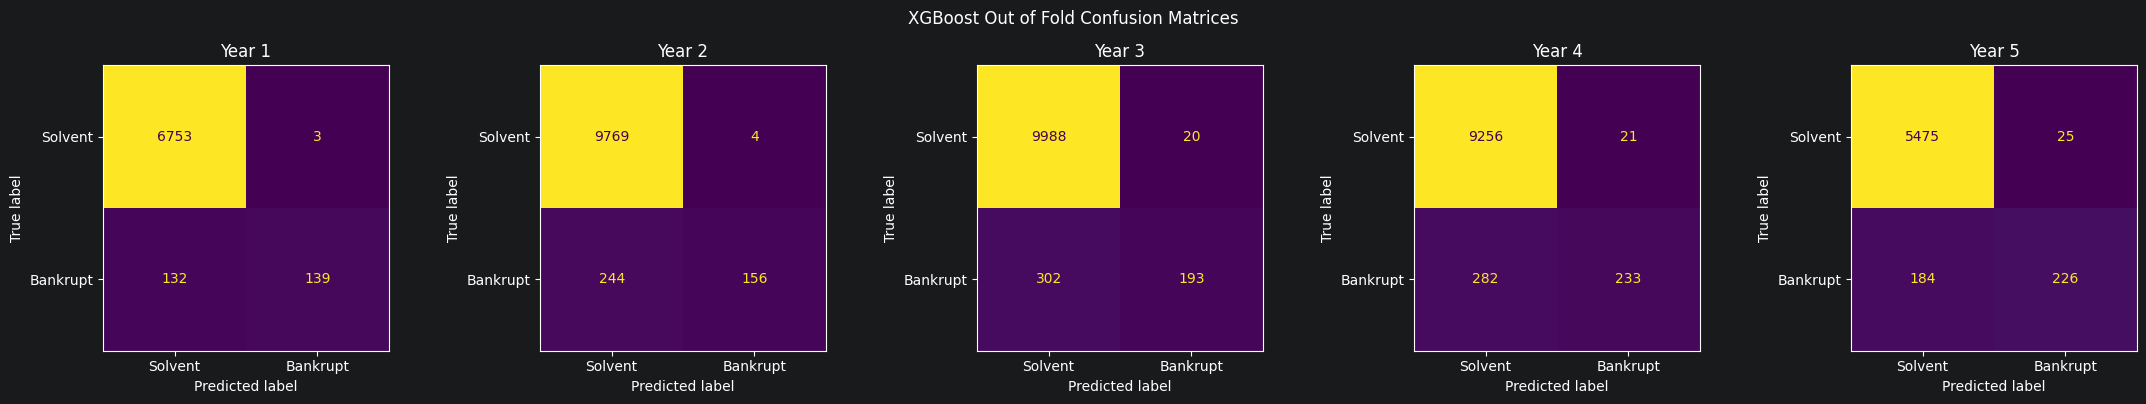

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, year in zip(axes, years):
    year_target = bankruptcy_data[year]["bankrupt"]
    oof_pred = (xgb_oof_proba[year] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        year_target, oof_pred, display_labels=["Solvent", "Bankrupt"], ax=ax, colorbar=False
    )
    ax.set_title(f"Year {year}")
fig.suptitle("XGBoost Out of Fold Confusion Matrices")
plt.tight_layout()
plt.show()

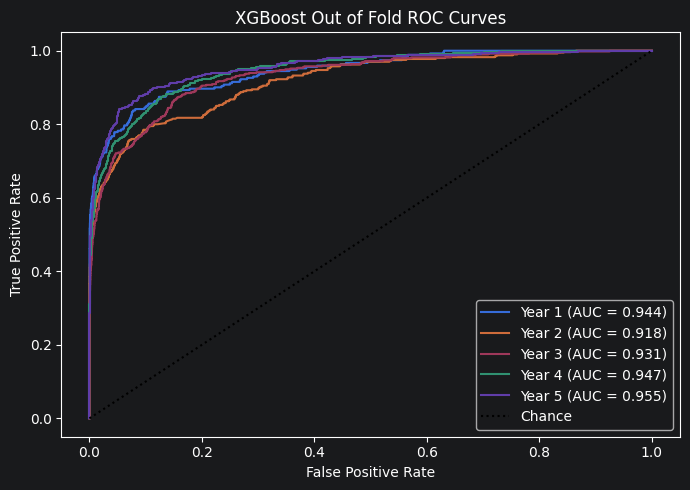

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
for year in years:
    year_target = bankruptcy_data[year]["bankrupt"]
    fpr, tpr, _ = roc_curve(year_target, xgb_oof_proba[year])
    oof_auc = roc_auc_score(year_target, xgb_oof_proba[year])
    ax.plot(fpr, tpr, label=f"Year {year} (AUC = {oof_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="dotted", color="black", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("XGBoost Out of Fold ROC Curves")
ax.legend()
plt.tight_layout()
plt.show()

XGBoost is also conservative at the 0.5 threshold, with bankrupt precision between 0.90 and 0.98 and recall between 0.39 and 0.55, but it catches noticeably more bankruptcies than Random Forest in years 2 through 4 (0.39 versus 0.29 in year 3, 0.45 versus 0.30 in year 4) at comparable precision. The confusion matrices show only 3 to 25 false alarms per year, and the ROC curves confirm the edge over Random Forest at every horizon, with out of fold AUC gains of 0.016 to 0.038.

## Conclusion

XGBoost is the stronger model at every level, posting out of fold AUC of 0.932 to 0.960 against 0.904 to 0.944 for Random Forest, with the biggest gains on the middle years where Random Forest struggled most. Against the paper, our tuned Random Forest significantly beats the reference RF in all five years, while our XGBoost matches or slightly exceeds the paper's featured XGB, with only year 3 reaching significance.

The class imbalance drives the rest of the narrative. ROC AUC was the right metric for tuning and comparison, and at the default 0.5 threshold both models are precise but miss a large share of bankruptcies, so a real deployment would lower the threshold based on the relative cost of a missed bankruptcy versus a false alarm. Finally, random search recovered nearly the full grid search score in a fraction of the time, which is what justified sampling 15 candidates from XGBoost's 729 combination space instead of exhausting it.